# Model: Drzewo decyzyjne
Badane hiperparametry: głębokość (max_depth), pruning (ccp_alpha), ważenie klas (class_weight)

## Wybór metryk

Zadanie polega na maksymalizacji zysku banku, dlatego główną metryką jest całkowity zysk liczony na podstawie macierzy pomyłek i wynagrodzenia każdego klienta:
- **TP** - poprawnie wykryty odchodzący klient, otrzymuje zniżkę -> bank zarabia 0.1% salary
- **TN** - lojalny klient, brak zniżki -> bank zarabia 0.3% salary  
- **FP** - lojalny klient dostaje niepotrzebną zniżkę -> bank zarabia tylko 0.1% salary (strata 0.2%)
- **FN** - odchodzący klient niewykryty -> bank traci klienta całkowicie (0%)

Accuracy jest tu myląca - model przewidujący zawsze "zostaje" osiągałby 79.6% accuracy przy zerowym zysku ponad baseline. Dodatkowo raportujemy AUC-ROC jako miarę ogólnej zdolności rozróżniania klas niezależnie od progu decyzyjnego.

In [ ]:
import sys
sys.path.append("..")

import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

from src.preprocessing import load_data, get_preprocessed_split
from src.metrics import calculate_profit, profit_summary, tune_threshold, cv_with_threshold

### Ładowanie danych


In [45]:
df = load_data()
X_train, X_test, y_train, y_test, salaries_train, salaries_test, preprocessor = get_preprocessed_split(df)

print(X_train.shape, X_test.shape)

(8000, 16) (2000, 16)


## Model bazowy
Domyślne hiperparametry — punkt odniesienia do późniejszych badań.

In [46]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

y_pred = base_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, base_model.predict_proba(X_test)[:, 1]):.4f}")
profit_summary(y_test, y_pred, salaries_test)

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1592
           1       0.48      0.54      0.51       408

    accuracy                           0.79      2000
   macro avg       0.68      0.70      0.69      2000
weighted avg       0.80      0.79      0.79      2000

AUC-ROC: 0.6979
Nasz model:                 463544.95 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  258798.56 $
Przewaga nad no_discount:   -26622.48 $


{'model': np.float64(463544.95),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

Jak widzimy model bazowy poradzil sobie gorzej niz gdybysmy nie robili nic. Musimy wprowadzić tuning hiperparametrów



## Badanie max_depth

In [47]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results_depth = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    cv_result = cv_with_threshold(model, X_train, y_train.values, salaries_train, n_splits=5)
    results_depth.append({
        "max_depth": str(d),
        "mean_profit": cv_result["mean"],
        "std_profit": cv_result["std"]
    })
    print(f"max_depth={str(d):>4}  zysk={cv_result['mean']:>12.2f} ± {cv_result['std']:.2f}")

max_depth=   2  zysk=   380099.39 ± 6123.55
max_depth=   3  zysk=   383671.88 ± 6883.59
max_depth=   4  zysk=   384282.80 ± 7287.14
max_depth=   5  zysk=   384919.68 ± 6747.49
max_depth=   6  zysk=   384456.60 ± 6248.00
max_depth=   8  zysk=   382247.15 ± 7499.11
max_depth=  10  zysk=   378515.51 ± 7342.12
max_depth=None  zysk=   360389.38 ± 8207.26


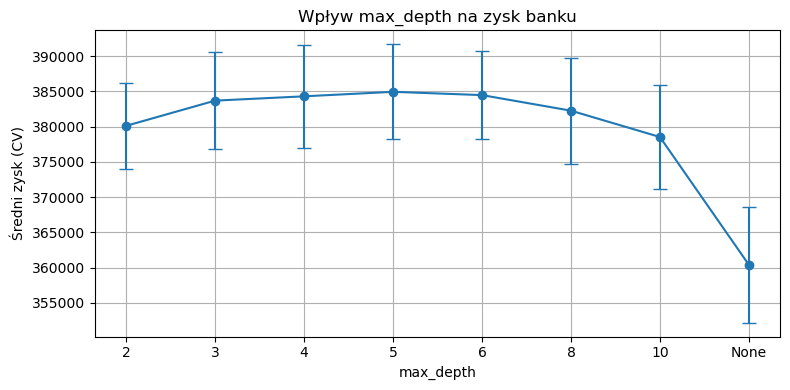

In [48]:
depths_labels = [str(d) for d in depths]
means = [r["mean_profit"] for r in results_depth]
stds = [r["std_profit"] for r in results_depth]

plt.figure(figsize=(8, 4))
plt.errorbar(depths_labels, means, yerr=stds, marker='o', capsize=5)
plt.xlabel("max_depth")
plt.ylabel("Średni zysk (CV)")
plt.title("Wpływ max_depth na zysk banku")
plt.grid(True)
plt.tight_layout()
plt.show()

Optimum to max_depth=5 z zyskiem 385,479$. Zbyt płytkie drzewa (depth=2) nie wykrywają odchodzących klientów, zbyt głębokie (None) są przeuczone.

## Badanie pruningu (ccp_alpha)

In [49]:
alphas = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
results_alpha = []

for a in alphas:
    model = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    cv_result = cv_with_threshold(model, X_train, y_train.values, salaries_train, n_splits=5)
    results_alpha.append({
        "ccp_alpha": a,
        "mean_profit": cv_result["mean"],
        "std_profit": cv_result["std"]
    })
    print(f"ccp_alpha={a:.4f}  zysk={cv_result['mean']:>12.2f} ± {cv_result['std']:.2f}")

ccp_alpha=0.0000  zysk=   360389.38 ± 8207.26
ccp_alpha=0.0001  zysk=   360546.15 ± 8130.86
ccp_alpha=0.0005  zysk=   383037.05 ± 7750.61
ccp_alpha=0.0010  zysk=   384653.45 ± 6921.31
ccp_alpha=0.0050  zysk=   382771.76 ± 5531.05
ccp_alpha=0.0100  zysk=   380099.39 ± 6123.55
ccp_alpha=0.0500  zysk=   159231.20 ± 2457.30


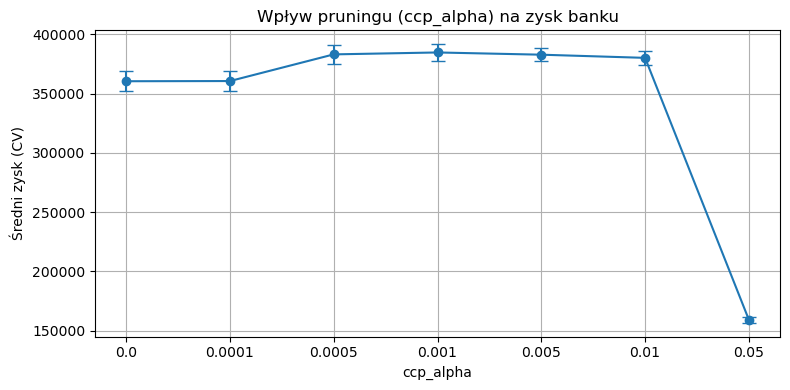

In [50]:
alphas_labels = [str(a) for a in alphas]
means_alpha = [r["mean_profit"] for r in results_alpha]
stds_alpha = [r["std_profit"] for r in results_alpha]

plt.figure(figsize=(8, 4))
plt.errorbar(alphas_labels, means_alpha, yerr=stds_alpha, marker='o', capsize=5)
plt.xlabel("ccp_alpha")
plt.ylabel("Średni zysk (CV)")
plt.title("Wpływ pruningu (ccp_alpha) na zysk banku")
plt.grid(True)
plt.tight_layout()
plt.show()

Najlepszy pruning to ccp_alpha=0.001 z zyskiem 385,990$. Zbyt agresywne przycinanie (alpha=0.05) drastycznie obniża zysk do 159,231$ - drzewo staje się zbyt proste.

## Badanie class_weight

In [51]:
weights = [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}]
results_weight = []

for w in weights:
    model = DecisionTreeClassifier(class_weight=w, random_state=42)
    cv_result = cv_with_threshold(model, X_train, y_train.values, salaries_train, n_splits=5)
    results_weight.append({
        "class_weight": str(w),
        "mean_profit": cv_result["mean"],
        "std_profit": cv_result["std"]
    })
    print(f"class_weight={str(w):>20}  zysk={cv_result['mean']:>12.2f} ± {cv_result['std']:.2f}")

class_weight=                None  zysk=   360389.38 ± 8207.26
class_weight=            balanced  zysk=   359402.03 ± 6275.91
class_weight=        {0: 1, 1: 2}  zysk=   359107.76 ± 5799.41
class_weight=        {0: 1, 1: 3}  zysk=   359574.47 ± 7321.35
class_weight=        {0: 1, 1: 5}  zysk=   362839.41 ± 5040.56


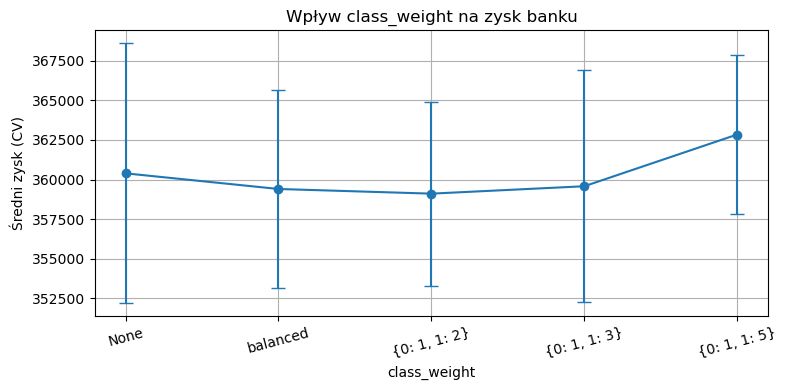

In [52]:
weights_labels = [str(w) for w in weights]
means_weight = [r["mean_profit"] for r in results_weight]
stds_weight = [r["std_profit"] for r in results_weight]

plt.figure(figsize=(8, 4))
plt.errorbar(weights_labels, means_weight, yerr=stds_weight, marker='o', capsize=5)
plt.xlabel("class_weight")
plt.ylabel("Średni zysk (CV)")
plt.title("Wpływ class_weight na zysk banku")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Ważenie klas nieznacznie poprawia wyniki - najlepsze jest class_weight={0: 1, 1: 5} z zyskiem 362,839$. Efekt jest jednak mniejszy niż przy tuningu głębokości i pruningu, ponieważ cv_with_threshold już automatycznie dobiera optymalny próg decyzyjny.

## Najlepszy model
Łączymy najlepsze hiperparametry z każdego badania.

In [53]:
best_model = DecisionTreeClassifier(
    max_depth=5,
    ccp_alpha=0.001,
    class_weight={0: 1, 1: 5},
    random_state=42
)

cv_result = cv_with_threshold(best_model, X_train, y_train.values, salaries_train, n_splits=5)
print(f"CV zysk: {cv_result['mean']:.2f} ± {cv_result['std']:.2f}")

CV zysk: 382986.91 ± 7148.62


Połączenie najlepszych hiperparametrów daje CV zysk 382,986$ ± 7,527$. Wynik jest nieco niższy niż najlepsze indywidualne wartości.

## Ocena na zbiorze testowym

In [54]:
best_model.fit(X_train, y_train)

scores_train = best_model.predict_proba(X_train)[:, 1]
best_threshold, _ = tune_threshold(y_train.values, scores_train, salaries_train)
print(f"Optymalny próg: {best_threshold:.4f}")

scores_test = best_model.predict_proba(X_test)[:, 1]
y_pred = (scores_test >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, scores_test):.4f}")
profit_summary(y_test, y_pred, salaries_test)

Optymalny próg: 0.9363
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1592
           1       0.82      0.37      0.51       408

    accuracy                           0.86      2000
   macro avg       0.84      0.68      0.71      2000
weighted avg       0.85      0.86      0.83      2000

AUC-ROC: 0.8483
Nasz model:                 499096.51 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  294350.12 $
Przewaga nad no_discount:     8929.08 $


{'model': np.float64(499096.51),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

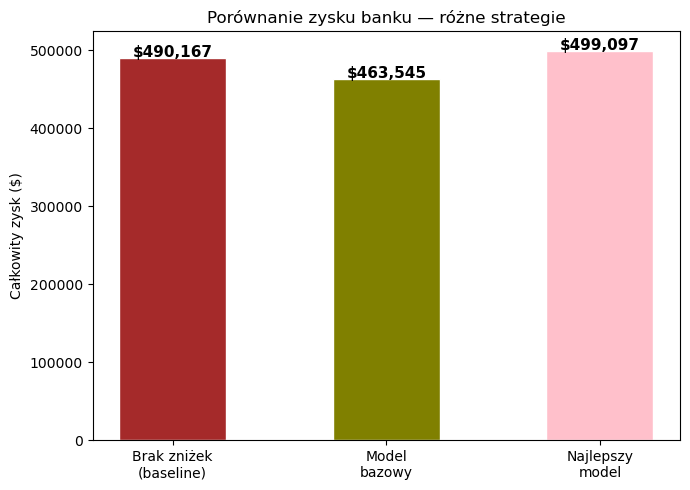

In [55]:
import matplotlib.pyplot as plt
import numpy as np

strategie = ["Brak zniżek\n(baseline)", "Model\nbazowy", "Najlepszy\nmodel"]
zyski = [490167.43, 463544.95, 499096.51]
kolory = ["brown", "olive", "pink"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(strategie, zyski, color=kolory, edgecolor="white", width=0.5)
for bar, val in zip(bars, zyski):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"${val:,.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Całkowity zysk ($)")
ax.set_title("Porównanie zysku banku — różne strategie")
plt.tight_layout()
plt.show()

Finalny model osiąga AUC-ROC 0.85 i zysk 499,097$ - o 35,552$ więcej niż model bazowy i o 8,929$ więcej niż strategia z brakiem znizek. Optymalny próg decyzyjny wynosi 0.94, co oznacza że model jest ostrożny z przyznawaniem zniżek - zgodnie z logiką biznesową.

## Zapis modelu

In [ ]:

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/decision_tree.pkl")
joblib.dump(best_threshold, "../models/decision_tree_threshold.pkl")
print("Model zapisany.")

Model zapisany.
